In [ ]:
import pandas as pd
df = pd.read_csv("C:/Users/HP/PycharmProjects/Drug-Recommendation-MLOps/Data/drug200.csv")
df.head()
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print(df.columns.tolist())
df.info()
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print(df["Drug"].value_counts())


In [4]:
import pandas as pd

df = pd.read_csv("C:/Users/HP/PycharmProjects/Drug-Recommendation-MLOps/Data/drug200.csv")

df.head()


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


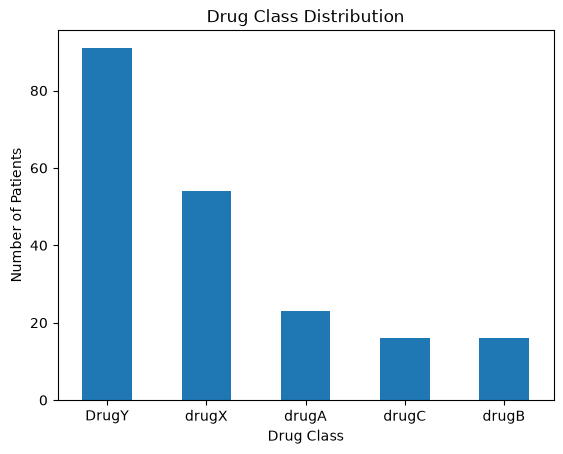

In [5]:
import matplotlib.pyplot as plt

df["Drug"].value_counts().plot(kind="bar")

plt.title("Drug Class Distribution")
plt.xlabel("Drug Class")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

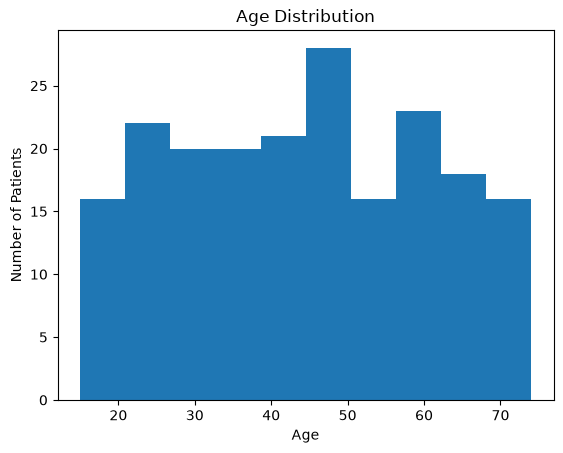

In [6]:
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

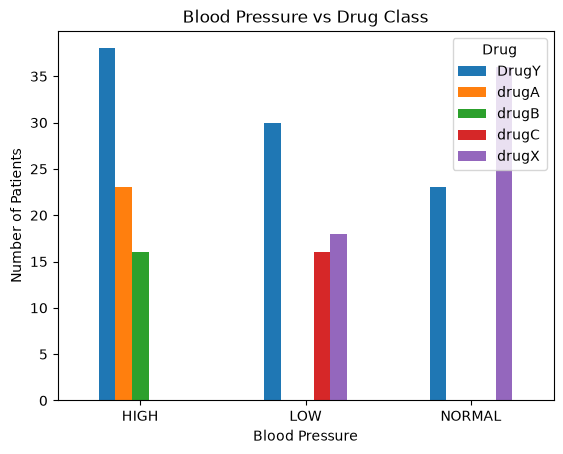

In [7]:
pd.crosstab(df["BP"], df["Drug"]).plot(kind="bar")

plt.title("Blood Pressure vs Drug Class")
plt.xlabel("Blood Pressure")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

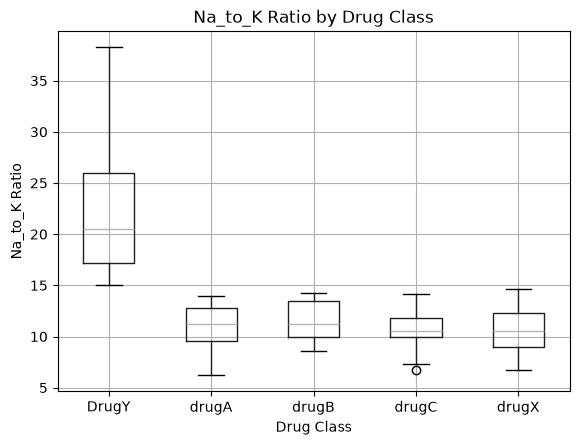

In [8]:
df.boxplot(column="Na_to_K", by="Drug")

plt.title("Na_to_K Ratio by Drug Class")
plt.suptitle("")
plt.xlabel("Drug Class")
plt.ylabel("Na_to_K Ratio")

plt.show()

In [9]:
X = df.drop("Drug", axis=1)
y = df["Drug"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'], dtype='str')

Target:
Drug


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["Age", "Na_to_K"]
categorical_features = ["Sex", "BP", "Cholesterol"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline updated successfully!")

Preprocessing pipeline updated successfully!


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

       DrugY       0.94      0.94      0.94        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      0.67      0.80         3
       drugC       1.00      1.00      1.00         3
       drugX       0.92      1.00      0.96        11

    accuracy                           0.95        40
   macro avg       0.97      0.92      0.94        40
weighted avg       0.95      0.95      0.95        40



In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [18]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_tree = decision_tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.975

Classification Report:
              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [20]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_rf = random_forest_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.975

Classification Report:
              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



In [21]:
model_results = {
    "Logistic Regression": [accuracy, 0.95],
    "Decision Tree": [accuracy_tree, 0.97],
    "Random Forest": [accuracy_rf, 0.97]
}

results_df = pd.DataFrame(
    model_results,
    index=["Accuracy", "Weighted F1"]
).T

results_df

,Accuracy,Weighted F1
Logistic Regression,0.950,0.95
Decision Tree,0.975,0.97
Random Forest,0.975,0.97


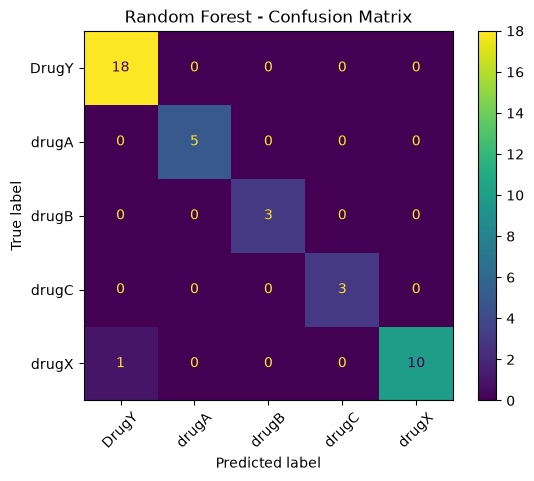

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    xticks_rotation=45
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [23]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    random_forest_model,
    "../models/drug_recommendation_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!
